# NOISE SPEECH

In [ ]:
import os
import pandas as pd

# Existing noise TSV
noise_tsv = "/run/media/fourier/Data1/Pras/Interspeech2025/RIRS_NOISES/data_augmentation_noises_labels.tsv"
speech_root = "/run/media/fourier/Data1/Pras/Interspeech2025/Datasets/MELD"
out_tsv = "/run/media/fourier/Data1/Pras/Interspeech2025/RIRS_NOISES/data_augmentation_noises_speechs_labels.tsv"

# Load existing noise TSV
df_noise = pd.read_csv(noise_tsv, sep="\t", header=None, names=["filepath", "label"])

# Collect all speech WAV files recursively
speech_paths = []
for root, _, files in os.walk(speech_root):
    for f in files:
        if f.lower().endswith(".wav"):
            speech_paths.append(os.path.join(root, f))

# Build speech dataframe
df_speech = pd.DataFrame({
    "filepath": speech_paths,
    "label": ["speech"] * len(speech_paths)
})

# Append
df_speech = df_speech.sample(n=842, random_state=32)
df_out = pd.concat([df_noise, df_speech], ignore_index=True)

# Save final TSV
df_out.to_csv(out_tsv, sep="\t", index=False, header=False)

print(f"Appended and saved to: {out_tsv}")
print(f"Noise count: {len(df_noise)}")
print(f"Speech count: {len(df_speech)}")
print(f"Total: {len(df_out)}")


# BUILD DB

In [1]:
import argparse, inspect, json, os, pickle, socket, subprocess, warnings, random, math, librosa, shutil
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from sklearn.metrics import accuracy_score, auc, balanced_accuracy_score, confusion_matrix, f1_score, roc_auc_score, roc_curve
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from tensorboard.backend.event_processing import event_accumulator
from torch.amp import GradScaler
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
from transformers import AutoConfig, AutoFeatureExtractor, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import torchaudio

import warnings
warnings.simplefilter("ignore", UserWarning)

def plot_one_per_db(df_concat):
    # Select one representative row per db cluster
    sampled = df_concat.groupby("db").apply(lambda x: x.sample(1)).reset_index(drop=True)

    plt.figure(figsize=(14, 6))

    for _, row in sampled.iterrows():
        filepath = f"{row['path_file']}"
        waveform, sr = torchaudio.load(filepath)

        # Flatten multi-channel (if stereo)
        waveform = waveform.mean(dim=0)

        # Normalize amplitude for visual comparability
        waveform = waveform / waveform.abs().max()

        t = torch.linspace(0, len(waveform) / sr, steps=len(waveform))
        plt.plot(t, waveform, alpha=0.8, label=f"db={row['db']}")

    plt.title("Waveform Overlay: One Representative Sample per db")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def filter_participants(df, participant_col, file_col, min_files=5, max_files=15, seed=42):
    """
    Normalize participant-level sample counts.
    - Remove participants with < min_files
    - Randomly downsample participants with > max_files
    - Keep only participants within the [min_files, max_files] band
    """
    # Compute counts
    counts = df.groupby(participant_col)[file_col].count()

    # Identify cohorts
    drop_ids = counts[counts < min_files].index
    downsample_ids = counts[counts > max_files].index

    # Filter low-volume participants
    df_filtered = df[~df[participant_col].isin(drop_ids)]

    # Downsample oversized participants
    output_frames = []
    for pid, group in df_filtered.groupby(participant_col):
        if pid in downsample_ids:
            group = group.sample(n=max_files, random_state=seed)
        output_frames.append(group)

    return pd.concat(output_frames, ignore_index=True)


def balance_participants(
    df,
    participant_col="participant",
    label_col="disease_status",
    ratio=1.0,
    seed=42,
    minority_label=None,
):
    """
    Balances the dataset by sampling participants, not individual rows.

    minority_label:
        None → auto-detect minority class based on participant counts
        0 or 1 → force a specific class to be treated as minority
    """

    # Participant → label mapping
    p_map = df.groupby(participant_col)[label_col].first()

    # Participant counts per class
    counts = p_map.value_counts()

    # Determine minority size
    if minority_label is None:
        minority_size = counts.min()
    else:
        # Forced minority: its size = actual participant count of that label
        minority_size = counts[minority_label]

    # Cap for majority classes
    majority_cap = int(minority_size * ratio)

    keep_pids = []

    for label in counts.index:
        pids = p_map[p_map == label]

        if label == minority_label:
            # Keep minority participants fully
            keep_pids.extend(pids.index)
        else:
            # Apply capping to majority groups
            if len(pids) > majority_cap:
                pids = pids.sample(majority_cap, random_state=seed)
            keep_pids.extend(pids.index)

    return df[df[participant_col].isin(keep_pids)].reset_index(drop=True)

def sample_rows_by_participant(df, target_rows=3042, participant_col="participant", label_col="disease_status", random_state=42):
    """
    Sample rows from a dataframe per participant while roughly balancing classes.

    Args:
        df (pd.DataFrame): DataFrame containing participants and labels.
        target_rows (int): Approximate total number of rows to sample.
        participant_col (str): Column name for participant IDs.
        label_col (str): Column name for labels.
        random_state (int): Seed for reproducibility.

    Returns:
        pd.DataFrame: Sampled dataframe.
    """
    # Group participants by their label
    participants = df.groupby(participant_col)[label_col].first().reset_index()

    # Shuffle participants per class
    classes = participants[label_col].unique()
    class_participants = {}
    for c in classes:
        class_participants[c] = participants[participants[label_col] == c].sample(frac=1, random_state=random_state)

    # Helper to select participants until target rows reached
    def select_participants(part_df, target_rows):
        selected = []
        total_rows = 0
        for p in part_df[participant_col]:
            part_rows = len(df[df[participant_col] == p])
            if total_rows + part_rows > target_rows:
                break
            selected.append(p)
            total_rows += part_rows
        return selected

    # Roughly split target rows evenly across classes
    rows_per_class = target_rows // len(classes)
    selected_participants = []
    for c in classes:
        selected_participants += select_participants(class_participants[c], rows_per_class)

    # Filter original dataframe
    df_sampled = df[df[participant_col].isin(selected_participants)]

    return df_sampled


def assign_split_column(
    df,
    participant_col="participant",
    label_col="disease_status",
    train_ratio=0.7,  # adjusted to leave space for val
    val_ratio=0.1,    # fraction of participants for validation
    seed=42
):
    """
    Stratified participant split into train/val/test.
    Guarantees:
        • No participant overlap
        • Class-wise train/val/test ratio per participant
        • Approximate row-level ratios
    """
    # Participant → label
    p_map = df.groupby(participant_col)[label_col].first()

    train_pids = []
    val_pids = []
    test_pids = []

    rng = np.random.default_rng(seed)

    for label in p_map.unique():
        pids = p_map[p_map == label].index
        n_total = len(pids)
        
        n_train = int(n_total * train_ratio)
        n_val = int(n_total * val_ratio)
        
        # shuffle participants
        shuffled = rng.permutation(pids)
        train_sel = shuffled[:n_train]
        val_sel = shuffled[n_train:n_train+n_val]
        test_sel = shuffled[n_train+n_val:]

        train_pids.extend(train_sel)
        val_pids.extend(val_sel)
        test_pids.extend(test_sel)

    # assign split
    df = df.copy()
    df["split"] = "train"
    df.loc[df[participant_col].isin(val_pids), "split"] = "val"
    df.loc[df[participant_col].isin(test_pids), "split"] = "test"

    return df


def encode_participants(df, participant_col="participant"):
    """
    Encode participants as numeric speaker IDs.

    Args:
        df (pd.DataFrame): DataFrame containing a participant column.
        participant_col (str): Column name for participant IDs.
        new_col (str): Name of the new numeric column.

    Returns:
        pd.DataFrame: DataFrame with an additional numeric speaker_id column.
    """
    df = df.copy()
    participant_mapping = {p: i for i, p in enumerate(df[participant_col].unique())}
    df[participant_col] = df[participant_col].map(participant_mapping)
    return df

# ALL DB

In [ ]:
df_coda_extra = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/3modalities_elbicare_v2/CODA_TB_additional_variables_train.csv')
df_longi = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/coda/longitudinal_original.csv')
df_longi = df_longi.rename(columns={"tb_status": "disease_status"})
df_longi = filter_participants(df_longi, "participant", "path_file", min_files=5, max_files=20, seed=42)
#df_longi = balance_participants(df_longi, participant_col="participant", label_col="disease_status", ratio=1.0, minority_label=1, seed=42)
df_longi = assign_split_column(df_longi, train_ratio=0.8, val_ratio=0.0)
df_longi = df_longi.merge(
    df_coda_extra[["participant", "HIVstatus"]],
    on="participant",
    how="left"
)
df_longi = df_longi.rename(columns={"sex": "gender", "smoke_lweek": "smoker", 'HIVstatus': 'hiv'})
df_longi["db"] = 0
df_longi = df_longi[['path_file', 'participant', 'gender', 'disease_status', 'weight_loss', 'hemoptysis', 'smoker', 'night_sweats', 'hiv', 'split', 'db']]
cols = ["weight_loss", "hemoptysis", "smoker", "night_sweats"]
df_longi[cols] = df_longi[cols].replace({"Yes": 1, "No": 0}).astype("Int64")
df_longi['gender'] = df_longi['gender'].replace({'Male': 0, 'Female': 1}).astype("Int64")
df_longi['hiv'] = df_longi['hiv'].replace({'Negative': 0, 'Positive': 1, 'Unknown': np.nan})

df_solic = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/coda/solicited_original.csv')
df_solic = df_solic.rename(columns={"tb_status": "disease_status"})
df_solic = filter_participants(df_solic, "participant", "path_file", min_files=5, max_files=20, seed=42)
#df_solic = balance_participants(df_solic, participant_col="participant", label_col="disease_status", ratio=1.3, minority_label=1, seed=42)
df_solic = assign_split_column(df_solic, train_ratio=0.8, val_ratio=0.0)
df_solic = df_solic.merge(
    df_coda_extra[["participant", "HIVstatus"]],
    on="participant",
    how="left"
)
df_solic = df_solic.rename(columns={"sex": "gender", "smoke_lweek": "smoker", 'HIVstatus': 'hiv'})
df_solic["db"] = 1
df_solic = df_solic[['path_file', 'participant', 'gender', 'disease_status', 'weight_loss', 'hemoptysis', 'smoker', 'night_sweats', 'hiv', 'split', 'db']]
cols = ["weight_loss", "hemoptysis", "smoker", "night_sweats"]
df_solic[cols] = df_solic[cols].replace({"Yes": 1, "No": 0})
df_solic['gender'] = df_solic['gender'].replace({'Male': 0, 'Female': 1})
df_solic['hiv'] = df_solic['hiv'].replace({'Negative': 0, 'Positive': 1, 'Unknown': np.nan})

df_tbscreen_solic = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/TBscreen_Dataset/metadata_solicited.csv')
df_tbscreen_solic = filter_participants(df_tbscreen_solic, "participant", "path_file", min_files=5, max_files=20, seed=42)
#df_tbscreen_solic = balance_participants(df_tbscreen_solic, participant_col="participant", label_col="disease_status", ratio=1.3, minority_label=1, seed=42)
df_tbscreen_solic = assign_split_column(df_tbscreen_solic, train_ratio=0.7, val_ratio=0.0)
df_tbscreen_solic = df_tbscreen_solic.rename(columns={"sex": "gender", "smkr_a": "smoker", "un_wght_loss": "weight_loss", 
                                    "nght_swts": "night_sweats", "cough_bld": "hemoptysis", "hiv_infected_a" : 'hiv'})
df_tbscreen_solic["db"] = 3
df_tbscreen_solic = df_tbscreen_solic[['path_file', 'participant', 'gender', 'disease_status', 'weight_loss', 'hemoptysis', 'smoker', 'night_sweats', 'hiv', 'split', 'db']]
df_tbscreen_solic['hiv'] = pd.to_numeric(df_tbscreen_solic['hiv'].replace({'Unknown': np.nan}))
df_tbscreen_solic['smoker'] = df_tbscreen_solic['smoker'].replace({2: 1})

df_tbscreen_longi = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/TBscreen_Dataset/metadata_longitudinal.csv')
df_tbscreen_longi = filter_participants(df_tbscreen_longi, "participant", "path_file", min_files=5, max_files=20, seed=42)
#df_tbscreen_longi = balance_participants(df_tbscreen_longi, participant_col="participant", label_col="disease_status", ratio=1.3, minority_label=1, seed=42)
df_tbscreen_longi = assign_split_column(df_tbscreen_longi, train_ratio=0.8, val_ratio=0.0)
df_tbscreen_longi = df_tbscreen_longi.rename(columns={"sex": "gender", "smkr_a": "smoker", "un_wght_loss": "weight_loss", 
                                    "nght_swts": "night_sweats", "cough_bld": "hemoptysis", "hiv_infected_a" : 'hiv'})
df_tbscreen_longi["db"] = 2
df_tbscreen_longi = df_tbscreen_longi[['path_file', 'participant', 'gender', 'disease_status', 'weight_loss', 'hemoptysis', 'smoker', 'night_sweats', 'hiv', 'split', 'db']]
df_tbscreen_longi['hiv'] = pd.to_numeric(df_tbscreen_longi['hiv'].replace({'Unknown': np.nan}))
df_tbscreen_longi['smoker'] = df_tbscreen_longi['smoker'].replace({2: 1})

df_cirdz = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/cirdz/metadata_wavs.csv')
df_cirdz =  df_cirdz[df_cirdz['recorder_type']  == 0]
df_cirdz = df_cirdz.rename(columns={"ground_truth_tb": "disease_status", "anon_id": "participant"})
df_cirdz = filter_participants(df_cirdz, "participant", "path_file", min_files=5, max_files=20, seed=42)
df_cirdz = assign_split_column(df_cirdz, train_ratio=1.0, val_ratio=0.0)
df_cirdz = df_cirdz.rename(columns={"sex": "gender", "tobacco_use": "smoker", "haemoptysis": "hemoptysis", "ngtsweats": "night_sweats",
                                    "weightloss": "weight_loss", "body_wt": "weight", "height": "height", "hiv_status": 'hiv'})
df_cirdz["db"] = 4
df_cirdz = df_cirdz[['participant', 'path_file', 'gender', 'age', 'weight_loss', 'hemoptysis', 'smoker', 'night_sweats', "hiv", 'disease_status', 'split', "db"]]
df_cirdz['path_file'] = "/run/media/fourier/Data1/Pras/DatabaseLLM/cirdz/" + df_cirdz['path_file']
cols = ["weight_loss", "hemoptysis", "night_sweats"]
df_cirdz[cols] = df_cirdz[cols].replace({"yes": 1, "no": 0})
df_cirdz['smoker'] = df_cirdz['smoker'].replace({'current': 1, 'never': 0, 'stopped': 1})
df_cirdz['gender'] = df_cirdz['gender'].replace({'m': 0, 'f': 1})
df_cirdz['hiv'] = df_cirdz['hiv'].replace({'neg': 0, 'pos': 1})
df_cirdz = df_cirdz.dropna(subset=["hemoptysis"])
df_cirdz = df_cirdz[['path_file', 'participant', 'gender', 'disease_status', 'weight_loss', 'hemoptysis', 'smoker', 'night_sweats', 'split', "db"]]
df_cirdz.to_csv("/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/cirdz.csv.test", index=False)

df_concat = pd.concat([df_longi, df_solic, df_tbscreen_solic, df_tbscreen_longi], axis=0, ignore_index=True)
#df_concat = df_concat.rename(columns={"path_file":"path_file_audio"})
df_concat['disease_status'].value_counts()
df_concat = df_concat[['path_file', 'participant', 'gender', 'disease_status', 'weight_loss', 'hemoptysis', 'smoker', 'night_sweats', 'split', 'db']]
print(df_concat[df_concat['split'] == 'train']['disease_status'].value_counts())
print(df_concat[df_concat['split'] == 'val']['disease_status'].value_counts())
print(df_concat[df_concat['split'] == 'test']['disease_status'].value_counts())

In [ ]:
plot_one_per_db(df_concat)

In [ ]:
df_concat = encode_participants(df_concat)
df_concat['gender']  = df_concat['gender'].replace({'Male': 0, 'Female': 1})

print(df_concat['disease_status'].value_counts())
print(df_concat['db'].value_counts())

for split_name in df_concat['split'].unique():
    split_df = df_concat[df_concat['split'] == split_name].copy()
    filename = f"/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/metadata.csv.{split_name}"
    split_df.to_csv(filename, index=False)
    print(f"Saved {split_name} split: {len(split_df)} rows → {filename}")

# SOLICITED ONLY

In [2]:
df_coda_extra = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/3modalities_elbicare_v2/CODA_TB_additional_variables_train.csv')
df_solic = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/coda/solicited_original.csv')
df_solic = df_solic.rename(columns={"tb_status": "disease_status"})
#df_solic = filter_participants(df_solic, "participant", "path_file", min_files=5, max_files=20, seed=42)
#df_solic = balance_participants(df_solic, participant_col="participant", label_col="disease_status", ratio=1.3, minority_label=1, seed=42)
#df_solic = assign_split_column(df_solic, train_ratio=0.8, val_ratio=0.0)
df_solic['split'] = 'train'
df_solic = df_solic.merge(
    df_coda_extra[["participant", "HIVstatus"]],
    on="participant",
    how="left"
)
df_solic = df_solic.rename(columns={"sex": "gender", "smoke_lweek": "smoker", 'HIVstatus': 'hiv'})
df_solic["db"] = 1
df_solic = df_solic[['path_file', 'participant', 'gender', 'disease_status', 'weight_loss', 'hemoptysis', 'smoker', 'night_sweats', 'hiv', 'split', 'db']]
cols = ["weight_loss", "hemoptysis", "smoker", "night_sweats"]
df_solic[cols] = df_solic[cols].replace({"Yes": 1, "No": 0})
df_solic['gender'] = df_solic['gender'].replace({'Male': 0, 'Female': 1})
df_solic['hiv'] = df_solic['hiv'].replace({'Negative': 0, 'Positive': 1, 'Unknown': np.nan})

df_tbscreen_solic = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/TBscreen_Dataset/metadata_solicited.csv')
df_tbscreen_solic = filter_participants(df_tbscreen_solic, "participant", "path_file", min_files=5, max_files=20, seed=42)
#df_tbscreen_solic = balance_participants(df_tbscreen_solic, participant_col="participant", label_col="disease_status", ratio=1.3, minority_label=1, seed=42)
#df_tbscreen_solic = assign_split_column(df_tbscreen_solic, train_ratio=0.7, val_ratio=0.0)
df_tbscreen_solic['split'] = 'train'
df_tbscreen_solic = df_tbscreen_solic.rename(columns={"sex": "gender", "smkr_a": "smoker", "un_wght_loss": "weight_loss", 
                                    "nght_swts": "night_sweats", "cough_bld": "hemoptysis", "hiv_infected_a" : 'hiv'})
df_tbscreen_solic["db"] = 3
df_tbscreen_solic = df_tbscreen_solic[['path_file', 'participant', 'gender', 'disease_status', 'weight_loss', 'hemoptysis', 'smoker', 'night_sweats', 'hiv', 'split', 'db']]
df_tbscreen_solic['hiv'] = pd.to_numeric(df_tbscreen_solic['hiv'].replace({'Unknown': np.nan}))
df_tbscreen_solic['smoker'] = df_tbscreen_solic['smoker'].replace({2: 1})

df_concat = pd.concat([df_solic], axis=0, ignore_index=True)
#df_concat = df_concat.rename(columns={"path_file":"path_file_audio"})
df_concat['disease_status'].value_counts()
df_concat = df_concat[['path_file', 'participant', 'gender', 'disease_status', 'weight_loss', 'hemoptysis', 'smoker', 'night_sweats', 'split', 'db']]
print(df_concat[df_concat['split'] == 'train']['disease_status'].value_counts())
print(df_concat[df_concat['split'] == 'val']['disease_status'].value_counts())
print(df_concat[df_concat['split'] == 'test']['disease_status'].value_counts())

disease_status
0    6506
1    2773
Name: count, dtype: int64
Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)


/tmp/ipykernel_3974340/428789667.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_solic[cols] = df_solic[cols].replace({"Yes": 1, "No": 0})
/tmp/ipykernel_3974340/428789667.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_solic['gender'] = df_solic['gender'].replace({'Male': 0, 'Female': 1})
/tmp/ipykernel_3974340/428789667.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To op

/tmp/ipykernel_3974340/1776844376.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled = df_concat.groupby("db").apply(lambda x: x.sample(1)).reset_index(drop=True)


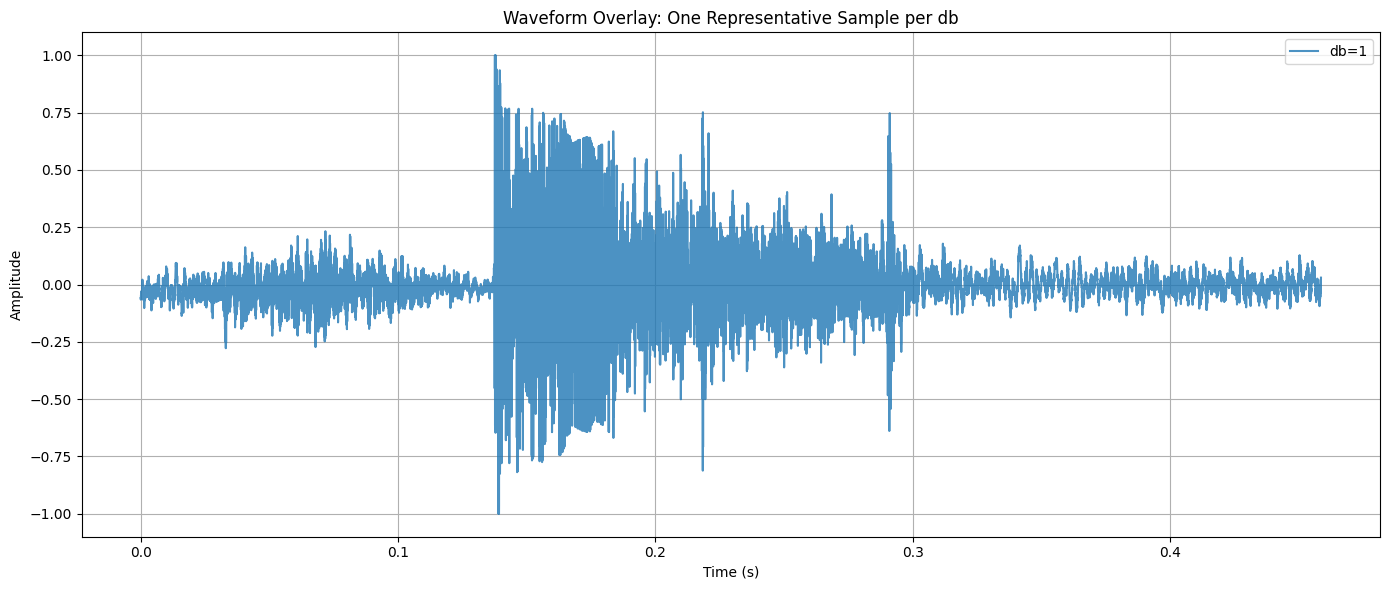

In [6]:
plot_one_per_db(df_concat)

In [7]:
df_concat['split'].unique()

array(['train'], dtype=object)

In [8]:
df_concat = encode_participants(df_concat)
df_concat['gender']  = df_concat['gender'].replace({'Male': 0, 'Female': 1})

print(df_concat['disease_status'].value_counts())
print(df_concat['db'].value_counts())

for split_name in df_concat['split'].unique():
    split_df = df_concat[df_concat['split'] == split_name].copy()
    filename = f"/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/metadata_coda_solicited.csv.{split_name}"
    split_df.to_csv(filename, index=False)
    print(f"Saved {split_name} split: {len(split_df)} rows → {filename}")

disease_status
0    6506
1    2773
Name: count, dtype: int64
db
1    9279
Name: count, dtype: int64
Saved train split: 9279 rows → /run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/metadata_coda_solicited.csv.train


# Try SYMPTOMS

In [ ]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

def compute_confusion_stats(y_true, y_pred, labels=(0, 1)):
    """
    Returns TN, FP, FN, TP for binary classification.
    """
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    assert cm.shape == (2, 2), f"Expected binary confusion matrix, got {cm.shape}"

    TN, FP = cm[0, 0], cm[0, 1]
    FN, TP = cm[1, 0], cm[1, 1]

    return TN, FP, FN, TP


def compute_clinical_metrics(TN, FP, FN, TP):
    """
    Sensitivity, specificity, balanced accuracy.
    """
    sens = TP / (TP + FN) if (TP + FN) > 0 else 0.0   # TB recall
    spec = TN / (TN + FP) if (TN + FP) > 0 else 0.0   # non-TB recall
    b_acc = 0.5 * (sens + spec)

    return {
        "sens": sens,
        "spec": spec,
        "bal_acc": b_acc,
    }


def compute_auc_metrics(y_true, y_prob):
    """
    AUROC and ROC curve primitives.
    """
    auroc = roc_auc_score(y_true, y_prob)
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)

    return auroc, fpr, tpr, thresholds


def compute_partial_auroc(
    fpr,
    tpr,
    min_tpr=0.80,
    min_spec=0.60,
):
    """
    Partial AUROC under clinical constraints:
    TPR >= min_tpr and SPEC >= min_spec.
    """
    spec_curve = 1.0 - fpr
    mask = (tpr >= min_tpr) & (spec_curve >= min_spec)

    if mask.sum() > 1:
        return np.trapz(tpr[mask], fpr[mask])
    else:
        return 0.0


def evaluate_binary_classifier(
    y_true,
    y_pred,
    y_prob,
):
    """
    End-to-end evaluation wrapper.
    """
    TN, FP, FN, TP = compute_confusion_stats(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)

    clinical = compute_clinical_metrics(TN, FP, FN, TP)
    auroc, fpr, tpr, _ = compute_auc_metrics(y_true, y_prob)
    p_auroc = compute_partial_auroc(fpr, tpr)

    return {
        "acc": acc,
        "bal_acc": clinical["bal_acc"],
        "sens": clinical["sens"],
        "spec": clinical["spec"],
        "auroc": auroc,
        "p_auroc": p_auroc,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "TP": TP,
    }


In [ ]:
df_concat = (
    df_concat
    .sort_values("participant")
    .groupby("participant", as_index=False)
    .first()
)



In [38]:
df_cirdz = pd.read_csv("/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/cirdz.csv.test")
df_cirdz = (
    df_cirdz
    .sort_values("participant")
    .groupby("participant", as_index=False)
    .first()
)

In [41]:
features = ['weight_loss', 'hemoptysis', 'smoker', 'night_sweats']
df_train = df_concat[df_concat['split'] == 'train']
df_test = df_concat[df_concat['split'] == 'test']

X_train = df_train[features].astype(float)
y_train = df_train["disease_status"].astype(int)

X_test = df_test[features].astype(float)
y_test = df_test["disease_status"].astype(int)

X_unseen = df_cirdz[features].astype(float)
y_unseen = df_cirdz["disease_status"].astype(int)

In [44]:
# Logistic Regression pipeline (scaling is critical)
logreg_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l2",
            solver="liblinear",     # stable for small/medium datasets
            class_weight="balanced",# important for medical imbalance
            max_iter=1000,
            random_state=42
        ))
    ]
)
logreg_model.fit(X_train, y_train)

# Train
y_pred = logreg_model.predict(X_train)
y_prob = logreg_model.predict_proba(X_train)[:, 1]
metrics = evaluate_binary_classifier(y_train, y_pred, y_prob)
print(
    f"Train - "
    f"Acc {metrics['acc']:.4f} | "
    f"BalAcc {metrics['bal_acc']:.4f} | "
    f"Sens {metrics['sens']:.4f} | "
    f"Spec {metrics['spec']:.4f} | "
    f"AUROC {metrics['auroc']:.4f} | "
    f"pAUROC {metrics['p_auroc']:.4f}"
)

# Test
y_pred = logreg_model.predict(X_test)
y_prob = logreg_model.predict_proba(X_test)[:, 1]
metrics = evaluate_binary_classifier(y_test, y_pred, y_prob)
print(
    f"Test - "
    f"Acc {metrics['acc']:.4f} | "
    f"BalAcc {metrics['bal_acc']:.4f} | "
    f"Sens {metrics['sens']:.4f} | "
    f"Spec {metrics['spec']:.4f} | "
    f"AUROC {metrics['auroc']:.4f} | "
    f"pAUROC {metrics['p_auroc']:.4f}"
)

# Unseen
y_pred = logreg_model.predict(X_unseen)
y_prob = logreg_model.predict_proba(X_unseen)[:, 1]
metrics = evaluate_binary_classifier(y_unseen, y_pred, y_prob)
print(
    f"Unseen - "
    f"Acc {metrics['acc']:.4f} | "
    f"BalAcc {metrics['bal_acc']:.4f} | "
    f"Sens {metrics['sens']:.4f} | "
    f"Spec {metrics['spec']:.4f} | "
    f"AUROC {metrics['auroc']:.4f} | "
    f"pAUROC {metrics['p_auroc']:.4f}"
)


Train - Acc 0.6836 | BalAcc 0.6580 | Sens 0.5945 | Spec 0.7216 | AUROC 0.7244 | pAUROC 0.0000
Test - Acc 0.6368 | BalAcc 0.6404 | Sens 0.6500 | Spec 0.6308 | AUROC 0.6562 | pAUROC 0.0000
Unseen - Acc 0.6187 | BalAcc 0.5705 | Sens 0.5000 | Spec 0.6410 | AUROC 0.5653 | pAUROC 0.0000


In [36]:
df_cirdz

,path_file,participant,gender,disease_status,weight_loss,hemoptysis,smoker,night_sweats,split,db
0,/run/media/fourier/Data1/Pras/DatabaseLLM/cird...,1037813678,0,1,0,0.0,0,1,train,4
1,/run/media/fourier/Data1/Pras/DatabaseLLM/cird...,1037813678,0,1,0,0.0,0,1,train,4
2,/run/media/fourier/Data1/Pras/DatabaseLLM/cird...,1037813678,0,1,0,0.0,0,1,train,4
3,/run/media/fourier/Data1/Pras/DatabaseLLM/cird...,1037813678,0,1,0,0.0,0,1,train,4
4,/run/media/fourier/Data1/Pras/DatabaseLLM/cird...,1037813678,0,1,0,0.0,0,1,train,4
...,...,...,...,...,...,...,...,...,...,...
850,/run/media/fourier/Data1/Pras/DatabaseLLM/cird...,9397098420,1,0,0,0.0,0,0,train,4
851,/run/media/fourier/Data1/Pras/DatabaseLLM/cird...,9397098420,1,0,0,0.0,0,0,train,4
852,/run/media/fourier/Data1/Pras/DatabaseLLM/cird...,9397098420,1,0,0,0.0,0,0,train,4
853,/run/media/fourier/Data1/Pras/DatabaseLLM/cird...,9397098420,1,0,0,0.0,0,0,train,4


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

features = [
    'weight_loss', 'hemoptysis', 'smoker', 'night_sweats'
]

df_train = df_concat#[df_concat['db'] == 4]

X = df_train[features].astype(float)
y = df_train["disease_status"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

models = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            class_weight="balanced",
            max_iter=1000
        ))
    ]),
    "SVM-RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel="rbf",
            probability=True,
            class_weight="balanced"
        ))
    ]),
    "DecisionTree": DecisionTreeClassifier(
        max_depth=5,
        class_weight="balanced",
        random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=500,
        max_depth=6,
        class_weight="balanced",
        random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values(
    by="roc_auc", ascending=False
)

print(results_df)

                model  accuracy   roc_auc
4    GradientBoosting  0.683565  0.720400
3        RandomForest  0.669081  0.719796
2        DecisionTree  0.665181  0.719796
0  LogisticRegression  0.674095  0.716705
1             SVM-RBF  0.669081  0.700254


In [ ]:
# import torch
# import torch.nn as nn

# class TabularNN(nn.Module):
#     def __init__(self, input_dim=4, num_classes=2):
#         super().__init__()

#         self.tabular_encoder = nn.Sequential(
#             nn.Linear(input_dim, 32),
#             nn.BatchNorm1d(32),
#             nn.ReLU(),
#             nn.Dropout(0.5),
#             nn.Linear(32, 128),
#             nn.ReLU(),
#         )

#         self.classifier = nn.Linear(128, num_classes)

#     def forward(self, x):
#         feats = self.tabular_encoder(x)
#         logits = self.classifier(feats)
#         return logits

# X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
# y_train_t = torch.tensor(y_train.values, dtype=torch.long)

# X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
# y_test_t = torch.tensor(y_test.values, dtype=torch.long)

# model = TabularNN(input_dim=X_train.shape[1], num_classes=2)
# criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# model.train()
# for epoch in range(50):
#     optimizer.zero_grad()
#     logits = model(X_train_t)
#     loss = criterion(logits, y_train_t)
#     loss.backward()
#     optimizer.step()

#     if epoch % 10 == 0:
#         print(f"Epoch {epoch} | Loss {loss.item():.4f}")

Epoch 0 | Loss 0.7065
Epoch 10 | Loss 0.6883
Epoch 20 | Loss 0.6754
Epoch 30 | Loss 0.6631
Epoch 40 | Loss 0.6512


In [22]:
model.eval()
with torch.no_grad():
    logits = model(X_train_t)
    probs = torch.softmax(logits, dim=1)[:, 1]
    preds = torch.argmax(logits, dim=1)

y_true = y_train_t.cpu().numpy()
y_pred = preds.cpu().numpy()
y_prob = probs.cpu().numpy()

metrics = evaluate_binary_classifier(y_true, y_pred, y_prob)

print(
    f"Train - "
    f"Acc {metrics['acc']:.4f} | "
    f"BalAcc {metrics['bal_acc']:.4f} | "
    f"Sens {metrics['sens']:.4f} | "
    f"Spec {metrics['spec']:.4f} | "
    f"AUROC {metrics['auroc']:.4f} | "
    f"pAUROC {metrics['p_auroc']:.4f}\n"
)


Train - Acc 0.6823 | BalAcc 0.5473 | Sens 0.1267 | Spec 0.9679 | AUROC 0.6223 | pAUROC 0.0000



In [23]:
model.eval()
with torch.no_grad():
    logits = model(X_test_t)
    probs = torch.softmax(logits, dim=1)[:, 1]
    preds = torch.argmax(logits, dim=1)

y_true = y_test_t.cpu().numpy()
y_pred = preds.cpu().numpy()
y_prob = probs.cpu().numpy()

metrics = evaluate_binary_classifier(y_true, y_pred, y_prob)

print(
    f"Test - "
    f"Acc {metrics['acc']:.4f} | "
    f"BalAcc {metrics['bal_acc']:.4f} | "
    f"Sens {metrics['sens']:.4f} | "
    f"Spec {metrics['spec']:.4f} | "
    f"AUROC {metrics['auroc']:.4f} | "
    f"pAUROC {metrics['p_auroc']:.4f}\n"
)


Test - Acc 0.6830 | BalAcc 0.5447 | Sens 0.1131 | Spec 0.9764 | AUROC 0.6256 | pAUROC 0.0000



In [ ]:
model.eval()
with torch.no_grad():
    logits = model(X_test_t)
    probs = torch.softmax(logits, dim=1)[:, 1]
    preds = torch.argmax(logits, dim=1)

y_true = y_test_t.cpu().numpy()
y_pred = preds.cpu().numpy()
y_prob = probs.cpu().numpy()

metrics = evaluate_binary_classifier(y_true, y_pred, y_prob)

print(
    f"Test - "
    f"Acc {metrics['acc']:.4f} | "
    f"BalAcc {metrics['bal_acc']:.4f} | "
    f"Sens {metrics['sens']:.4f} | "
    f"Spec {metrics['spec']:.4f} | "
    f"AUROC {metrics['auroc']:.4f} | "
    f"pAUROC {metrics['p_auroc']:.4f}\n"
)


Test - Acc 0.6819 | BalAcc 0.6561 | Sens 0.5754 | Spec 0.7367 | AUROC 0.6578 | pAUROC 0.0000



In [ ]:
logreg = models["LogisticRegression"]
coef = logreg.named_steps["clf"].coef_[0]

logreg_importance = pd.Series(
    np.abs(coef),
    index=features
).sort_values(ascending=False)

print("Logistic Regression importance")
print(logreg_importance)


In [ ]:
def tree_importance(model, name):
    return pd.Series(
        model.feature_importances_,
        index=features
    ).sort_values(ascending=False).rename(name)

rf_imp = tree_importance(models["RandomForest"], "RandomForest")
gb_imp = tree_importance(models["GradientBoosting"], "GradientBoosting")
dt_imp = tree_importance(models["DecisionTree"], "DecisionTree")


In [ ]:
importance_df = pd.concat(
    [logreg_importance, rf_imp, gb_imp, dt_imp],
    axis=1
)

importance_df["mean_rank"] = importance_df.rank(
    ascending=False
).mean(axis=1)

importance_df = importance_df.sort_values("mean_rank")

print(importance_df)


In [ ]:
importance_df = pd.concat(
    [logreg_importance, rf_imp, gb_imp, dt_imp],
    axis=1
)

importance_df["mean_rank"] = importance_df.rank(
    ascending=False
).mean(axis=1)

importance_df = importance_df.sort_values("mean_rank")

print(importance_df)

In [ ]:
df_concat

In [ ]:
df_train_ukcovid = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/ukcovid19/metadata.csv.train')
df_val_ukcovid = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/ukcovid19/metadata.csv.val')
df_test_ukcovid = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/ukcovid19/metadata.csv.test')

df_train_ukcovid = df_train_ukcovid.rename(columns={"file_path": "path_file", 'covid_test_result': 'disease_status', 'gender': 'sex', 'participant_identifier': 'participant'})
df_val_ukcovid = df_val_ukcovid.rename(columns={"file_path": "path_file", 'covid_test_result': 'disease_status', 'gender': 'sex', 'participant_identifier': 'participant'})
df_test_ukcovid = df_test_ukcovid.rename(columns={"file_path": "path_file", 'covid_test_result': 'disease_status', 'gender': 'sex', 'participant_identifier': 'participant'})

df_train_ukcovid = filter_participants(df_train_ukcovid, "participant", "path_file", min_files=5, max_files=20, seed=42)
df_val_ukcovid = filter_participants(df_val_ukcovid, "participant", "path_file", min_files=5, max_files=20, seed=42)
df_test_ukcovid = filter_participants(df_test_ukcovid, "participant", "path_file", min_files=5, max_files=20, seed=42)

df_train_ukcovid = sample_rows_by_participant(df_train_ukcovid, target_rows=5000, participant_col="participant", label_col="disease_status")
df_val_ukcovid = sample_rows_by_participant(df_val_ukcovid, target_rows=338, participant_col="participant", label_col="disease_status")
df_test_ukcovid = sample_rows_by_participant(df_test_ukcovid, target_rows=1000, participant_col="participant", label_col="disease_status")

df_train_ukcovid['split'] = "train"
df_val_ukcovid['split'] = "val"
df_test_ukcovid['split'] = "test"

df_ukcovid = pd.concat([df_train_ukcovid, df_val_ukcovid, df_test_ukcovid], axis=0, ignore_index=True)
df_ukcovid["db"] = 5
df_ukcovid['disease_status'] = 0

df_concat = pd.concat([df_concat, df_ukcovid], axis=0, ignore_index=True)
df_concat = encode_participants(df_concat)
df_concat['sex']  = df_concat['sex'].replace({'Male': 0, 'Female': 1})

print(df_concat['disease_status'].value_counts())
print(df_concat['db'].value_counts())

In [ ]:
plot_one_per_db(df_concat)

# Try Dataloader

In [ ]:
%cd /run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough

import os, pickle, random, json
import pandas as pd
import numpy as np
import hashlib

import torch
import torchaudio
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchaudio import transforms as T
import torch.nn.functional as F
import torchvision.transforms as transforms

import librosa
from sklearn.utils import shuffle 

import utils, commons, audio_processing
from augmentation import DataAugmentator, ISD_additive_noise, LnL_convolutive_noise
from cough_datasets import CoughDatasets, CoughDatasetsCollate, CoughDatasetsProcessorCollate
from scipy.signal import resample

from IPython.display import display, Audio
import matplotlib.pyplot as plt

def seed_from_path(path):
    h = hashlib.md5(path.encode()).hexdigest()
    seed = int(h[:8], 16) 
    random.seed(seed)
    np.random.seed(seed)

with open("/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/configs/general.json", "r") as f:
    data = f.read()

config = json.loads(data)
hps = utils.HParams(**config)

df_train = pd.read_csv('/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/metadata.csv.train')
cols = hps.data.column_order
df_train = df_train[cols]

train_dataset = CoughDatasets(df_train.values, hps.data, train=True, wav_stats_path="logs/wavlmencoder_scl_attentive/wav_stats_fold_0.pickle")
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=train_dataset.sampling_rate,
    n_fft=hps.data.filter_length,
    hop_length=train_dataset.hop_length,
    n_mels=hps.data.n_mel_channels
)

In [ ]:
sample_data = df_train.sample(n=1).values[0][0]
audio_original = utils.load_audio_sample(sample_data, train_dataset.sampling_rate, train_dataset.saming_length, 
                                train_dataset.desired_length, fade_samples_ratio=train_dataset.fade_samples_ratio, 
                                pad_types="zero").squeeze().numpy()
#mel_original = torchaudio.functional.amplitude_to_DB(mel_transform(audio_original), multiplier=10, amin=1e-10, db_multiplier=0).squeeze().numpy()

audio_augment = train_dataset.data_augmentator.apply_reverb(audio_original, train_dataset.sampling_rate)

display(Audio(audio_original, rate=train_dataset.sampling_rate))
display(Audio(audio_augment, rate=train_dataset.sampling_rate))

In [ ]:
audio_augment.shape

In [ ]:
len(audio_augment)

In [ ]:
train_dataset

In [ ]:
audio_original

In [ ]:
plt.plot(audio_original)

In [ ]:
# Skema1

In [ ]:
def apply_fade_in(audio, sr, sec=0.08):
    fade_len = int(sr * sec)
    fade_len = min(fade_len, len(audio))
    fade = np.linspace(0.0, 1.0, fade_len)
    audio[:fade_len] *= fade
    return audio

def apply_fade_out(audio, sr, sec=0.08):
    fade_len = int(sr * sec)
    fade_len = min(fade_len, len(audio))
    fade = np.linspace(1.0, 0.0, fade_len)
    audio[-fade_len:] *= fade
    return audio

def speed_perturb(audio, factor_min=0.9, factor_max=1.1):
    factor = random.uniform(factor_min, factor_max)
    new_len = int(len(audio) / factor)
    out = resample(audio, new_len)
    return np.clip(out, -1.0, 1.0)

def gain_perturb(audio, db_range):
    low, high = db_range
    gain_db = random.uniform(low, high)
    gain = 10 ** (gain_db / 20)
    out = audio * gain
    return np.clip(out, -1.0, 1.0)

def generate_gap(sr, low=0.08, high=0.12, noise_gain=0.0001):
    gap_sec = random.uniform(low, high)
    gap_len = int(sr * gap_sec)
    noise = np.random.randn(gap_len) * noise_gain
    return np.clip(noise, -1.0, 1.0)

def build_tail_segment(audio, sr):
    tail_gap = generate_gap(sr, low=0.15, high=0.4)
    tail = audio.copy()

    tail = speed_perturb(tail)
    tail = gain_perturb(tail, (-5.0, -1.0))
    return np.concatenate([tail_gap, tail], axis=0)

def augment_and_merge(audio_original, path, sr, gain_db_set=[(-5.0, -1.0)]):
    seed_from_path(path)

    # fade-out original
    audio_faded = audio_original.copy()
    audio_faded = apply_fade_out(audio_faded, sr)

    # extract segment aligned to energy peak
    sec_i_start = max((audio_original ** 2).argmax() - 2400, 0)
    sec_segment = audio_original.copy()[sec_i_start:]

    # fade-in
    sec_segment = apply_fade_in(sec_segment, sr)

    # speed perturbation
    sec_segment = speed_perturb(sec_segment)

    # gain perturbation
    gain_db = random.choice(gain_db_set)
    sec_segment = gain_perturb(sec_segment, gain_db)

    # noise gap prepend
    gap_seg = generate_gap(sr)
    sec_segment = np.concatenate([gap_seg, sec_segment], axis=0)

    if random.random() < 0.40:
        tail_segment = build_tail_segment(sec_segment, sr)
        sec_segment = np.concatenate([sec_segment, tail_segment], axis=0)

    # merge
    merged = np.concatenate([audio_faded, sec_segment], axis=0)
    return merged


In [ ]:
merged = augment_and_merge(
    audio_original,
    path=sample_data,
    sr=train_dataset.sampling_rate
)

merged = augment_and_merge(
    merged,
    path=sample_data,
    sr=train_dataset.sampling_rate
)

display(Audio(merged, rate=train_dataset.sampling_rate))
plt.plot(merged)


In [ ]:
0.1, 0.085

In [ ]:
plt.plot(audio_original ** 2)

In [ ]:
#audio_augment = getattr(train_dataset.data_augmentator, "add_background_noise")(audio_original, train_dataset.sampling_rate)
audio_augment = train_dataset.data_augmentator(audio_original, train_dataset.sampling_rate).squeeze(0)
mel_augment = torchaudio.functional.amplitude_to_DB(mel_transform(audio_augment), multiplier=10, amin=1e-10, db_multiplier=0).squeeze().numpy()

display(Audio(audio_original.squeeze().cpu().numpy(), rate=train_dataset.sampling_rate))
display(Audio(audio_augment.squeeze().cpu().numpy(), rate=train_dataset.sampling_rate))

In [ ]:


ipd.Audio(audio.squeeze().cpu().numpy(), rate=train_dataset.sampling_rate)




plt.figure(figsize=(10, 4))
plt.imshow(mel_db.squeeze().numpy(), aspect='auto', origin='lower')
plt.colorbar(label='dB')
plt.title("Mel-Spectrogram")
plt.xlabel("Frames")
plt.ylabel("Mel bins")
plt.tight_layout()
plt.show()

In [ ]:

        audio = audio.squeeze(0)
        if train_dataset.augment_data and train_dataset.train:
            if random.uniform(0, 0.999) > 1 - 0.8:
                try:
                    audio = train_dataset.data_augmentator(audio.unsqueeze(0), train_dataset.sampling_rate).squeeze(0)
                except:
                    audio = audio

        original_feature_dtype = audio.dtype
        if train_dataset.augment_rawboost and train_dataset.train:        
            feature = LnL_convolutive_noise(audio.numpy(), 5, 5, 20, 8000, 100, 1000,
                                            10, 100, 0, 0, 5, 20, train_dataset.sampling_rate)
            feature = ISD_additive_noise(feature, 10, 2)
            if not isinstance(feature, torch.Tensor):
                feature = torch.tensor(feature)
            if feature.dtype != original_feature_dtype:
                feature = feature.to(original_feature_dtype)
            audio = feature

        if train_dataset.add_noise:
            audio = audio + torch.rand_like(audio)

        audio = audio.unsqueeze(0)
        return audio

In [ ]:
sample_audio = train_dataset.get_audio(sample_data)

In [ ]:
sample_audio.shape

In [ ]:
sample_data

In [ ]:
audio = utils.load_audio_sample(sample_data, train_dataset.sampling_rate, train_dataset.saming_length, 
                                    train_dataset.desired_length, fade_samples_ratio=train_dataset.fade_samples_ratio, 
                                    pad_types=train_dataset.pad_types) # repeat zero
    audio = audio.squeeze(0)
    if train_dataset.augment_data and train_dataset.train:
        if random.uniform(0, 0.999) > 1 - 0.8:
            try:
                audio = train_dataset.data_augmentator(audio.unsqueeze(0), train_dataset.sampling_rate).squeeze(0)
            except:
                audio = audio

    original_feature_dtype = audio.dtype
    if train_dataset.augment_rawboost and train_dataset.train:        
        feature = LnL_convolutive_noise(audio.numpy(), 5, 5, 20, 8000, 100, 1000,
                                        10, 100, 0, 0, 5, 20, train_dataset.sampling_rate)
        feature = ISD_additive_noise(feature, 10, 2)
        if not isinstance(feature, torch.Tensor):
            feature = torch.tensor(feature)
        if feature.dtype != original_feature_dtype:
            feature = feature.to(original_feature_dtype)
        audio = feature

    if train_dataset.add_noise:
        audio = audio + torch.rand_like(audio)

    audio = audio.unsqueeze(0)
    return audio

In [ ]:
# check augmented data, check 1/1 how augmentation effect

In [ ]:
# Vizualize

cough_volume = (
    df_solic
      .groupby("participant")["path_file"]
      .count()
      .sort_values(ascending=False)
)

plt.figure(figsize=(14,4))
cough_volume.plot(kind="bar")
plt.title("Cough Count Distribution per Participant")
plt.xlabel("Participant")
plt.ylabel("Cough Count")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2. COVID Test Result vs File Count
# ------------------------------------------------------------
covid_counts = (
    df_solic.groupby("disease_status")["path_file"]
      .count()
      .sort_values(ascending=False)
)

plt.figure(figsize=(6,4))
covid_counts.plot(kind="bar")
plt.title("File Volume by COVID Test Result")
plt.xlabel("COVID Test Result")
plt.ylabel("File Count")
plt.tight_layout()
plt.show()
